# S2Mosaic - Quick start

Mosaic an arbitrary bounding box of Sentinel-2 imagery in a few cells. This notebook is designed to run in Colab or locally with the package installed.

## 1. Install (Colab only)

The cell below installs `s2mosaic` only when running on Colab. If you've already got it installed locally, this is a no-op.

**Tip:** the default cloud mask (OmniCloudMask) is a CNN. On Colab, switch to a GPU runtime first — *Runtime → Change runtime type → T4 GPU* — for ~5–10× faster inference. Everything still works on CPU, just slower.

In [1]:
try:
    import google.colab  # type: ignore # noqa: F401

    # --pre installs the v2 beta; drop this flag once 2.0.0 ships stable.
    %pip install --pre -q s2mosaic
except ImportError:
    pass

## 2. Build a mosaic

We'll use Singapore's Marina Bay during the NE monsoon, a cloudy 4-month window where per-pixel cloud masking plus median aggregation is useful. On CPU-only machines, `cloud_mask="SCL"` is cheaper and usually faster than the default OCM model.

Bounds are passed in the local UTM zone (EPSG:32648 for Singapore) and `snap_to_source_grid=True` aligns the output to the native Sentinel-2 10 m grid — every output pixel is then a direct copy from the source with no resampling at the edges. Lon/lat (EPSG:4326) input also works, see [Advanced - wide area visual export.ipynb](Advanced%20-%20wide%20area%20visual%20export.ipynb).

In [2]:
from s2mosaic import mosaic

# To stream pipeline progress logs, uncomment:
# import s2mosaic
# s2mosaic.set_log_level("INFO")

# ~7.8km x 3.9km AOI over Marina Bay, Singapore.
# Coords are in UTM zone 48N (EPSG:32648) metres.
bounds = (366490, 139840, 374290, 143730)

array, profile = mosaic(
    bounds=bounds,
    input_crs=32648,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=11,  # NE monsoon: wet and cloudy
    duration_months=4,  # span Nov 2023 to Feb 2024
    bands=["B04", "B03", "B02"],  # red, green, blue
    mosaic_method="median",
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/23 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/54 [00:00<?, ?read/s]

Shape: (3, 389, 780)
CRS:   EPSG:32648
Pixel: 10.0m


## 3. Display the result

Quick percentile-stretch RGB plot. For a saved GeoTIFF instead, pass `output_dir=Path("output")` to `mosaic()`; it will then return the file path.

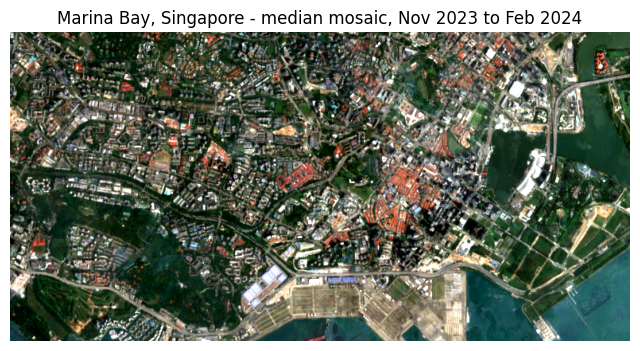

In [3]:
import numpy as np
from matplotlib import pyplot as plt


def plot_rgb(array, title=None, figsize=(8, 6)):
    """Display B04/B03/B02-style arrays with a robust percentile stretch."""
    rgb = np.moveaxis(array[:3], 0, -1).astype(float)
    valid = rgb[np.isfinite(rgb) & (rgb > 0)]
    if valid.size == 0:
        raise ValueError("No positive finite pixels to display")
    lo, hi = np.nanpercentile(valid, [2, 98])
    if not np.isfinite(hi - lo) or hi <= lo:
        hi = np.nanmax(valid)
        lo = np.nanmin(valid)
    rgb_disp = np.clip((rgb - lo) / max(hi - lo, 1), 0, 1)

    plt.figure(figsize=figsize)
    plt.imshow(rgb_disp)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


plot_rgb(array, "Marina Bay, Singapore - median mosaic, Nov 2023 to Feb 2024")

## What next?

- Switch to a different area: change the four numbers in `bounds` (UTM metres for the zone you pass as `input_crs`), or pass `input_crs=4326` and use lon/lat instead.
- Get a 4-band stack (R, G, B, NIR): `bands=["B04", "B03", "B02", "B08"]`.
- Mosaic an entire MGRS tile instead: pass `grid_id="48NUG"` (Singapore) and omit `bounds`.
- Running on a CPU-only machine? Pass `cloud_mask="SCL"` to use the L2A Scene Classification Layer instead of the deep-learning mask.
- Save a GeoTIFF plus request metadata: pass `output_dir=Path("output")`.